# Long-Short Harvest

This is a long-short equity strategy designed to harvest alpha from distorted market conditions. The long sleeve concentrates exposure in a small set of the largest U.S. equities, dynamically adjusting position sizes based on market regime signals. On the short side, the algorithm scans a broad, liquid equity universe for extended, trend-exhaustion candidates using multi-horizon Hurst-style measures, ATR-scaled extension filters, and momentum confirmation, with disciplined ATR-based stop exits. Together, the two sleeves operate independently but within a unified margin-aware framework, allowing the strategy to adapt across market environments while maintaining tight control over leverage, drawdowns, and execution risk.

---

## Strategy Architecture

| Sleeve | Universe | Signal | Rebalance | Risk Control |
|---|---|---|---|---|
| **Long** | Top 4 stocks by market cap | VIX regime + SPY trend + ML | Daily | 3-stage trailing stop |
| **Short** | Top 150 liquid large-caps | Hurst score + ATR extension + momentum | Weekly | ATR-based hard stop |

## Pipeline
1. **Data** — Download SPY, GLD, VIX and S&P 500 universe
2. **Long Sleeve** — Identify top-4 mega-caps, build VIX/SPY regime signals, train ML model
3. **Short Sleeve** — Score universe with Hurst + ATR filters, select top candidate
4. **Backtesting** — Simulate both sleeves daily with margin-aware position sizing
5. **Results** — Equity curve, drawdown, rolling Sharpe vs SPY

## 1. Imports & Config

In [1]:
import numpy as np
import pandas as pd
import yfinance as yf
import requests
import io
import warnings
import matplotlib.pyplot as plt
from datetime import datetime, timedelta

from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler

warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8-whitegrid')

# ── Strategy parameters ──────────────────────────────────────────────────────
TRAIN_START  = '2018-01-01'
TEST_START   = '2023-01-01'   # first date we trade (need warm-up before this)
TEST_END     = '2026-03-31'
INITIAL_CASH = 10_000

# Long sleeve
LONG_GROSS       = 0.90   # max gross long exposure
ML_TILT          = 0.25   # extra weight tilted to highest-cap top stock when ML is bullish
TOP_WEIGHT_MAX   = 0.35   # max weight per long position
TOP_N_LONG       = 4      # number of mega-cap longs
LONG_TRAIL_1     = 0.095  # trailing stop stage 1 (cut to 2/3)
LONG_TRAIL_2     = 0.070  # trailing stop stage 2 (cut to 1/3)
LONG_TRAIL_3     = 0.0485 # trailing stop stage 3 (full exit)

# Short sleeve
SHORT_GROSS      = 0.60   # max gross short exposure
TOP_N_SHORT      = 1      # number of simultaneous shorts
LOOKBACK_BARS    = 260    # bars for Hurst computation
N_LIST           = [10, 10, 40, 60, 90, 100]  # Hurst horizons
SMA_LEN          = 195    # SMA length for extension filter
EXT_K            = 2.0    # extension filter: price > SMA + ext_k * ATR20
MOM_K            = 1.75   # momentum filter: 5d return > mom_k * ATR20
SCORE_THRESHOLD  = 0.85   # minimum Hurst score to consider shorting
STOP_ATR         = 2.0    # short stop: exit if price rises stop_atr * entry_ATR

# ML model
MIN_TRAINING     = 504    # minimum bars before training ML
ML_RETRAIN_FREQ  = 21     # retrain every N trading days (~monthly)

print('Config loaded.')

Config loaded.


> 💬 **What this does:** We load all the Python libraries we need — numpy and pandas for maths and data tables, yfinance to download stock prices for free, scikit-learn for the machine learning model, and matplotlib to draw charts. Below the imports we set every strategy parameter in one place: how much to invest long vs short, when trailing stops kick in, how strict the short filter is, etc. Changing any of these numbers at the top automatically flows through to the whole strategy — you never need to hunt through the code.


## 2. Data Collection

- **SPY** and **GLD** for long-sleeve allocation
- **^VIX** for regime detection
- **S&P 500 universe** via Wikipedia for the short sleeve
- **Top-4 mega-caps** by market cap (AAPL, MSFT, NVDA, AMZN as a reasonable approximation — or pulled dynamically below)

In [2]:
# Pull S&P 500 tickers
url = 'https://en.wikipedia.org/wiki/List_of_S%26P_500_companies'
sp500 = pd.read_html(io.StringIO(requests.get(url, headers={'User-Agent': 'Mozilla/5.0'}).text))[0]
sp500['Symbol'] = sp500['Symbol'].str.replace('.', '-', regex=False)
sp500_tickers = sp500['Symbol'].tolist()
print(f'S&P 500 tickers: {len(sp500_tickers)}')

# Top mega-caps for the long sleeve (largest by market cap — stable over time)
# These are the consistent top-4 by market cap through most of our backtest period
TOP_LONG_TICKERS = ['AAPL', 'MSFT', 'NVDA', 'AMZN']

# Short universe: we'll use a liquid subset of S&P 500
# Download them in batches to avoid timeouts
SHORT_UNIVERSE_SIZE = 150

S&P 500 tickers: 503


> 💬 **What this does:** We pull the current list of S&P 500 companies from Wikipedia. This gives us ~500 ticker symbols that represent the largest US stocks. We use this list as the hunting ground for the short sleeve — we only consider large, liquid stocks so we can actually trade them without moving the price.


In [3]:
print('Downloading core data (SPY, GLD, VIX, top longs)...')
core_tickers = ['SPY', 'GLD', '^VIX'] + TOP_LONG_TICKERS
core_data = yf.download(core_tickers, start=TRAIN_START, end=TEST_END,
                        auto_adjust=True, progress=False)

spy_close  = core_data['Close']['SPY'].ffill()
gld_close  = core_data['Close']['GLD'].ffill()
vix_close  = core_data['Close']['^VIX'].ffill()
long_close = core_data['Close'][TOP_LONG_TICKERS].ffill()

print(f'Core data shape: {core_data["Close"].shape}')
print(f'Date range: {spy_close.index[0].date()} → {spy_close.index[-1].date()}')

Core data shape: (2071, 7)
Date range: 2018-01-02 → 2026-03-30


> 💬 **What this does:** We download daily price history for the four main instruments the strategy needs: SPY (the S&P 500 ETF, used as both a benchmark and a regime signal), GLD (gold ETF, used as a hedge when equities look risky), VIX (the 'fear index' — measures how anxious the market is), and the four mega-cap longs (AAPL, MSFT, NVDA, AMZN). We go back to 2015 so the machine learning model has plenty of history to learn from.


In [4]:
# Download short universe (first 150 S&P 500 tickers — most liquid)
# We use OHLCV data because the short sleeve needs high/low for ATR
print(f'Downloading short universe ({SHORT_UNIVERSE_SIZE} tickers)...')
short_tickers = [t for t in sp500_tickers[:SHORT_UNIVERSE_SIZE]
                 if t not in TOP_LONG_TICKERS + ['SPY', 'GLD']]

short_data = yf.download(short_tickers, start=TRAIN_START, end=TEST_END,
                         auto_adjust=True, progress=False)

short_close = short_data['Close'].ffill()
short_high  = short_data['High'].ffill()
short_low   = short_data['Low'].ffill()

# Drop tickers with too much missing data
valid = short_close.isnull().mean() < 0.1
short_tickers_clean = valid[valid].index.tolist()
short_close = short_close[short_tickers_clean]
short_high  = short_high[short_tickers_clean]
short_low   = short_low[short_tickers_clean]

print(f'Short universe after cleaning: {len(short_tickers_clean)} stocks')

Short universe after cleaning: 140 stocks


> 💬 **What this does:** We download full OHLC (open, high, low, close) data for the first 150 S&P 500 stocks. We need the high and low prices — not just the close — because the short sleeve uses ATR (Average True Range), which measures how much a stock typically moves each day. We then drop any tickers with more than 10% missing data to keep the universe clean.


## 3. Helper Functions

In [5]:
# ─── ATR ──────────────────────────────────────────────────────────────────────
def compute_atr(high: np.ndarray, low: np.ndarray, close: np.ndarray, n: int = 20) -> float:
    """Average True Range over last n bars."""
    if len(close) < n + 1:
        return np.nan
    trs = []
    for i in range(-n, 0):
        h, l, c_prev = high[i], low[i], close[i - 1]
        trs.append(max(h - l, abs(h - c_prev), abs(l - c_prev)))
    return float(np.mean(trs))


# ─── Hurst-style score ────────────────────────────────────────────────────────
def hurst_like(high: np.ndarray, low: np.ndarray, close: np.ndarray,
               n: int, bump: float) -> float:
    """
    Pseudo-Hurst exponent over n bars.
    H > 0.5 → trending; H < 0.5 → mean-reverting.
    bump nudges H away from 0.45 to sharpen the signal.
    """
    atr = compute_atr(high, low, close, n)
    if atr is None or atr <= 0 or len(high) < n:
        return np.nan
    span = float(np.max(high[-n:])) - float(np.min(low[-n:]))
    if span <= 0:
        return np.nan
    h = (np.log(span) - np.log(atr)) / np.log(n)
    h += bump if h > 0.45 else -bump
    return float(h)


def compute_hurst_score(high: np.ndarray, low: np.ndarray, close: np.ndarray,
                        n_list: list) -> float:
    """Average Hurst score across multiple horizons."""
    vals = []
    for n in n_list:
        bump = 0.01 + 0.0002 * n
        hv = hurst_like(high, low, close, n, bump)
        if not np.isnan(hv):
            vals.append(hv)
    if len(vals) < 4:
        return np.nan
    agree = sum(1 for x in vals if x > 0.6)
    return float(np.mean(vals)) + 0.02 * max(0, agree - 3)


# ─── ML features ─────────────────────────────────────────────────────────────
def get_ml_features(vix_arr: np.ndarray, spy_arr: np.ndarray) -> list:
    """Build feature vector for the RandomForest regime classifier."""
    if len(vix_arr) < 50 or len(spy_arr) < 200:
        return None
    vix = vix_arr[-1]
    vix_sma20 = np.mean(vix_arr[-20:])
    vix_sma50 = np.mean(vix_arr[-50:])
    vix_std   = np.std(vix_arr[-20:])
    vix_z     = (vix - vix_sma20) / vix_std if vix_std > 0 else 0.0
    vix_pct   = float(np.mean(vix_arr < vix))
    spy = spy_arr[-1]
    spy_sma50  = np.mean(spy_arr[-50:])
    spy_sma200 = np.mean(spy_arr[-200:])
    ret5   = spy_arr[-1] / spy_arr[-5]   - 1
    ret10  = spy_arr[-1] / spy_arr[-10]  - 1
    ret20  = spy_arr[-1] / spy_arr[-20]  - 1
    vol21  = np.std(np.diff(spy_arr[-21:]) / spy_arr[-21:-1]) * np.sqrt(252)
    return [
        float(vix), float(vix_z), float(vix_pct),
        float(vix / vix_sma20) if vix_sma20 else 1.0,
        float(vix / vix_sma50) if vix_sma50 else 1.0,
        float(ret5), float(ret10), float(ret20),
        float(spy / spy_sma50)  if spy_sma50  else 1.0,
        float(spy / spy_sma200) if spy_sma200 else 1.0,
        float(vol21),
    ]

print('Helper functions defined.')

Helper functions defined.


> 💬 **What this does:** These are the mathematical building blocks the strategy relies on.

**ATR (Average True Range)** measures how much a stock typically moves per day, accounting for overnight gaps. Think of it as the stock's 'normal daily wobble'. A stock at $100 with an ATR of $3 typically moves $3 a day.

**Hurst score** is a measure of whether a stock is trending or mean-reverting. A score above 0.5 means the stock tends to keep moving in the same direction (trending). The short sleeve looks for stocks with a very high Hurst score (≥0.85) because it wants stocks that have been relentlessly trending upward — those are the ones most likely to eventually exhaust and snap back.

**ML features** packages up 11 numbers about the current market state (VIX level, VIX trend, SPY momentum at various timeframes) into a format the machine learning model can read.


## 4. Long Sleeve — Regime Engine

Uses a five-regime VIX/SPY framework to decide how much gross equity exposure to hold in the top-4 mega-caps vs GLD (as a hedge).

| Regime | Condition | Equity weight | GLD weight |
|---|---|---|---|
| **Panic buy** | VIX > 80th pct & SPY 5d < -3% | 85–100% of long_gross | remainder |
| **Low vol** | VIX < 13 & SPY > SMA50×1.05 | 40% | 40% |
| **Elevated calm** | 20 < VIX < VIX SMA | 70–85% | remainder |
| **Spike** | VIX > VIX SMA × 1.2 | 0% | 50% |
| **Bull trend** | SPY > SMA200 | 70–90% | remainder |
| **Bear** | SPY < SMA200 | 30% | 50% |

In [6]:
def get_long_regime(vix_arr: np.ndarray, spy_arr: np.ndarray,
                    ml_bullish: bool = False) -> dict:
    """
    Returns target weights for equity (top-4 longs) and GLD
    based on the current VIX/SPY regime and ML signal.
    """
    if len(vix_arr) < 50 or len(spy_arr) < 200:
        return {'equity': 0.0, 'gld': 0.3}

    vix     = float(vix_arr[-1])
    vix_sma = float(np.mean(vix_arr[-20:]))
    vix_p80 = float(np.percentile(vix_arr, 80))

    spy     = float(spy_arr[-1])
    spy_sma50  = float(np.mean(spy_arr[-50:]))
    spy_sma200 = float(np.mean(spy_arr[-200:]))
    spy_5d_ret = float(spy_arr[-1] / spy_arr[-5] - 1)

    LG = LONG_GROSS

    # Regime 1: panic / dip-buy
    if vix > vix_p80 and spy_5d_ret < -0.03:
        eq_w = LG * (1.0 if ml_bullish else 0.85)
        return {'equity': eq_w, 'gld': LG * (1.0 - eq_w / LG)}

    # Regime 2: very low vol, extended
    if vix < 13 and spy > spy_sma50 * 1.05:
        return {'equity': LG * 0.40, 'gld': LG * 0.40}

    # Regime 3: elevated but below SMA (calming down)
    if 20 < vix < vix_sma:
        eq_w = LG * (0.85 if ml_bullish else 0.70)
        return {'equity': eq_w, 'gld': LG * (1.0 - eq_w / LG)}

    # Regime 4: VIX spike — risk-off
    if vix > vix_sma * 1.2:
        return {'equity': 0.0, 'gld': LG * 0.50}

    # Regime 5 / 6: trend following
    if spy > spy_sma200:
        base = 0.90 if ml_bullish else 0.70
        eq_w = LG * base
        return {'equity': eq_w, 'gld': LG * (1.0 - base)}
    else:
        return {'equity': LG * 0.30, 'gld': LG * 0.50}


print('Long regime function defined.')

Long regime function defined.


> 💬 **What this does:** This is the brain of the long sleeve. Every day it looks at the VIX and SPY and asks: 'what kind of market are we in right now?' Then it decides how much to put into stocks vs gold.

- **Panic / dip-buy**: VIX is spiking AND the market just fell hard → actually lean into equities (market is likely oversold)
- **Complacency**: VIX is very low AND stocks are extended → reduce equity, add gold as caution
- **Calming down**: VIX elevated but falling → moderate equity allocation
- **Fear spike**: VIX suddenly surges → go to zero equities, hold gold as protection  
- **Bull trend**: SPY above its 200-day average → normal equity allocation
- **Bear trend**: SPY below 200-day → cut equity sharply, hold gold

The machine learning signal can nudge each of these allocations up by ~25% if it thinks the market will be up in the next month.


## 5. Short Sleeve — Scoring Engine

Scans the short universe daily for overextended trending stocks. A stock qualifies when:
- **Hurst score ≥ 0.85** across 6 horizons (confirms sustained trend)
- **Extension filter**: `price > SMA195 + 2.0 × ATR20` (price stretched far above MA)
- **Momentum filter**: `5-day return > 1.75 × ATR20` (still pushing higher recently)

All three must be true simultaneously. The top-scoring candidate gets shorted.

In [7]:
def score_short_candidate(ticker: str, date_loc: int,
                          close_df: pd.DataFrame,
                          high_df: pd.DataFrame,
                          low_df: pd.DataFrame) -> dict:
    """
    Score a single ticker as a short candidate at a given date.
    Returns None if the stock doesn't qualify.
    """
    if date_loc < LOOKBACK_BARS + 10:
        return None

    start = date_loc - LOOKBACK_BARS
    c = close_df[ticker].iloc[start:date_loc].values
    h = high_df[ticker].iloc[start:date_loc].values
    l = low_df[ticker].iloc[start:date_loc].values

    if np.any(np.isnan(c)) or len(c) < max(N_LIST) + 6:
        return None

    # Hurst score
    score = compute_hurst_score(h, l, c, N_LIST)
    if np.isnan(score) or score < SCORE_THRESHOLD:
        return None

    # ATR
    atr20 = compute_atr(h, l, c, 20)
    if np.isnan(atr20) or atr20 <= 0:
        return None

    close_now = float(c[-1])
    sma = float(np.mean(c[-SMA_LEN:]))
    close_5 = float(c[-5])

    # Extension filter: price is stretched above the long MA
    ext_ok = (close_now - sma) > EXT_K * atr20
    # Momentum filter: still moving up strongly
    mom_ok = (close_now - close_5) > MOM_K * atr20

    if not (ext_ok and mom_ok):
        return None

    return {'ticker': ticker, 'score': score, 'price': close_now, 'atr': atr20}


print('Short scoring function defined.')

Short scoring function defined.


> 💬 **What this does:** This function decides whether a stock is worth shorting. A stock has to pass three tests simultaneously — if any one fails, it's skipped:

1. **Hurst score ≥ 0.85**: The stock must have been in a very strong, persistent uptrend across six different time horizons. This tells us the trend has been real and sustained, not just a one-day spike.

2. **Extension filter**: The stock's price must be more than 2× its daily ATR above its 195-day moving average. In plain English: the stock is stretched far above where it 'should' be based on recent history. Think of a rubber band pulled tight.

3. **Momentum filter**: The stock still moved up more than 1.75× its ATR in just the last 5 days. This confirms the trend is still active — we're not shorting something that already rolled over.

The idea is to find stocks that have been relentlessly trending up, are now overextended, but are still pushing higher — the rubber band is at maximum stretch. These are the best short candidates because when they snap back, they tend to move fast.


## 6. Backtest Engine

Simulates both sleeves daily:
- **Long sleeve**: runs every day, regime signal updated daily, ML retrained monthly
- **Short sleeve**: rescans universe weekly (Monday), risk-checks shorts daily
- **Position sizing**: both sleeves constrained by available margin (no margin calls)

In [8]:
def run_backtest():
    """
    Full backtest of the Long-Short Harvest strategy.
    Returns a DataFrame of daily portfolio values and a trade log.
    """
    # Align all series to a common trading calendar
    common_idx = spy_close.index
    common_idx = common_idx[(common_idx >= TRAIN_START) & (common_idx <= TEST_END)]

    # Only trade from TEST_START onward (need warm-up history)
    trade_idx = common_idx[common_idx >= TEST_START]

    # ── State ─────────────────────────────────────────────────────────────────
    cash     = float(INITIAL_CASH)
    # positions: {ticker: shares (negative = short)}
    positions = {}
    # trailing stop state for longs
    trail_state = {}  # {ticker: {'high': px, 'stage': 0, 'target_w': w}}
    # short entry info
    short_entry = {}  # {ticker: {'entry_price': px, 'entry_atr': atr}}

    # ML model
    model   = RandomForestClassifier(n_estimators=100, max_depth=5, random_state=42)
    scaler  = StandardScaler()
    trained = False
    last_train_day = -999

    portfolio_values = []
    trade_log = []

    def get_price(ticker, date):
        try:
            if ticker == 'SPY':  return float(spy_close.loc[date])
            if ticker == 'GLD':  return float(gld_close.loc[date])
            if ticker in long_close.columns: return float(long_close.loc[date, ticker])
            if ticker in short_close.columns: return float(short_close.loc[date, ticker])
        except:
            pass
        return np.nan

    def portfolio_value(date):
        pv = cash
        for ticker, shares in positions.items():
            px = get_price(ticker, date)
            if not np.isnan(px):
                pv += shares * px
        return pv

    def set_target_weight(ticker, target_w, date, pv, log_reason=''):
        """Trade to a target portfolio weight."""
        nonlocal cash
        px = get_price(ticker, date)
        if np.isnan(px) or px <= 0:
            return
        target_value  = pv * float(target_w)
        current_value = positions.get(ticker, 0) * px
        delta_value   = target_value - current_value
        delta_shares  = delta_value / px
        if abs(delta_shares) < 0.01:
            return
        positions[ticker] = positions.get(ticker, 0) + delta_shares
        cash -= delta_value
        if abs(positions.get(ticker, 0)) < 0.001:
            positions.pop(ticker, None)
        trade_log.append({'date': date, 'ticker': ticker,
                          'target_w': target_w, 'reason': log_reason})

    def liquidate(ticker, date, reason=''):
        nonlocal cash
        shares = positions.pop(ticker, 0)
        if shares == 0:
            return
        px = get_price(ticker, date)
        if not np.isnan(px):
            cash += shares * px
        trail_state.pop(ticker, None)
        short_entry.pop(ticker, None)
        trade_log.append({'date': date, 'ticker': ticker,
                          'target_w': 0.0, 'reason': reason})

    # ── Main loop ─────────────────────────────────────────────────────────────
    for day_i, date in enumerate(trade_idx):
        # Index in the full common_idx (for lookback slicing)
        full_loc = common_idx.get_loc(date)
        pv = portfolio_value(date)

        # ── ML: retrain monthly ───────────────────────────────────────────
        if day_i - last_train_day >= ML_RETRAIN_FREQ:
            vix_arr = vix_close.iloc[:full_loc].values
            spy_arr = spy_close.iloc[:full_loc].values
            if len(spy_arr) >= MIN_TRAINING and len(vix_arr) >= MIN_TRAINING:
                X_tr, y_tr = [], []
                for i in range(200, len(spy_arr) - 21):
                    feats = get_ml_features(vix_arr[:i], spy_arr[:i])
                    if feats:
                        label = 1 if spy_arr[i + 21] / spy_arr[i] > 1.02 else 0
                        X_tr.append(feats)
                        y_tr.append(label)
                if len(X_tr) >= 100:
                    X_tr = np.array(X_tr)
                    scaler.fit(X_tr)
                    model.fit(scaler.transform(X_tr), np.array(y_tr))
                    trained = True
                    last_train_day = day_i

        # ── ML signal for today ───────────────────────────────────────────
        ml_bullish = False
        if trained:
            vix_now = vix_close.iloc[:full_loc].values
            spy_now = spy_close.iloc[:full_loc].values
            feats = get_ml_features(vix_now, spy_now)
            if feats:
                proba = model.predict_proba(scaler.transform([feats]))[0]
                ml_bullish = float(proba[1]) > 0.6 if len(proba) == 2 else False

        # ── Long sleeve: daily regime allocation ──────────────────────────
        vix_arr = vix_close.iloc[max(0, full_loc-100):full_loc].values
        spy_arr = spy_close.iloc[max(0, full_loc-210):full_loc].values
        regime  = get_long_regime(vix_arr, spy_arr, ml_bullish)

        eq_total = regime['equity']
        n_longs  = len(TOP_LONG_TICKERS)

        # Equal weight the top longs (with optional ML tilt toward largest-cap)
        # For simplicity in this notebook AAPL gets the ML tilt (largest cap)
        if eq_total > 0:
            base_w = eq_total / n_longs
            weights = {t: base_w for t in TOP_LONG_TICKERS}
            if ml_bullish and ML_TILT > 0:
                extra = base_w * ML_TILT
                weights['AAPL'] = min(base_w + extra, TOP_WEIGHT_MAX)
                sub = extra / (n_longs - 1)
                for t in TOP_LONG_TICKERS:
                    if t != 'AAPL':
                        weights[t] = max(0.0, base_w - sub)
            for t, w in weights.items():
                set_target_weight(t, w, date, pv, 'long_regime')
                # Initialise trailing stop state
                if t not in trail_state:
                    px = get_price(t, date)
                    if not np.isnan(px):
                        trail_state[t] = {'high': px, 'stage': 0, 'target_w': w}
                else:
                    trail_state[t]['target_w'] = w
        else:
            for t in TOP_LONG_TICKERS:
                if positions.get(t, 0) > 0:
                    liquidate(t, date, 'regime_exit')

        # GLD allocation
        set_target_weight('GLD', regime['gld'], date, pv, 'gld_regime')

        # ── Long sleeve: trailing stop check ─────────────────────────────
        for t in list(trail_state.keys()):
            if positions.get(t, 0) <= 0:
                trail_state.pop(t, None)
                continue
            px = get_price(t, date)
            if np.isnan(px) or px <= 0:
                continue
            st = trail_state[t]
            if px > st['high']:
                st['high'] = px
            dd = (st['high'] - px) / st['high']
            tw = st['target_w']
            if st['stage'] == 0 and dd >= LONG_TRAIL_1:
                set_target_weight(t, tw * (2/3), date, pv, 'trail_stage1')
                st['stage'] = 1
                st['high'] = px
            elif st['stage'] == 1 and dd >= LONG_TRAIL_2:
                set_target_weight(t, tw * (1/3), date, pv, 'trail_stage2')
                st['stage'] = 2
                st['high'] = px
            elif st['stage'] == 2 and dd >= LONG_TRAIL_3:
                liquidate(t, date, 'trail_stop')

        # ── Short sleeve: weekly rescan (Monday approximation) ────────────
        if date.weekday() == 0:  # Monday
            candidates = []
            for ticker in short_tickers_clean:
                if ticker in TOP_LONG_TICKERS:
                    continue
                if ticker not in short_close.columns:
                    continue
                try:
                    t_loc = short_close.index.get_loc(date)
                except:
                    continue
                result = score_short_candidate(ticker, t_loc,
                                               short_close, short_high, short_low)
                if result:
                    candidates.append(result)

            candidates.sort(key=lambda x: x['score'], reverse=True)
            selected_shorts = [c['ticker'] for c in candidates[:TOP_N_SHORT]]

            # Exit shorts not in new selection
            for t in list(short_entry.keys()):
                if t not in selected_shorts:
                    liquidate(t, date, 'short_exit_rescan')

            # Enter new shorts
            for c in candidates[:TOP_N_SHORT]:
                t = c['ticker']
                if t not in short_entry:
                    w = -abs(SHORT_GROSS) / max(TOP_N_SHORT, 1)
                    set_target_weight(t, w, date, pv, 'short_entry')
                    short_entry[t] = {'entry_price': c['price'], 'entry_atr': c['atr']}

        # ── Short sleeve: daily stop check ───────────────────────────────
        for t, info in list(short_entry.items()):
            if positions.get(t, 0) >= 0:
                short_entry.pop(t, None)
                continue
            px = get_price(t, date)
            if np.isnan(px) or px <= 0:
                continue
            entry_px  = float(info['entry_price'])
            entry_atr = float(info['entry_atr'])
            if entry_atr > 0 and (px - entry_px) > STOP_ATR * entry_atr:
                liquidate(t, date, 'short_stop')

        portfolio_values.append({'date': date, 'portfolio_value': portfolio_value(date)})

    pv_df = pd.DataFrame(portfolio_values).set_index('date')
    trades_df = pd.DataFrame(trade_log)
    return pv_df, trades_df


print('Backtest engine defined. Ready to run.')

Backtest engine defined. Ready to run.


> 💬 **What this does:** This is the main simulation loop. It walks through every trading day from 2018 to 2024, one day at a time, and asks: 'given everything we know up to today, what would this strategy have done?'

At each day it:
1. Retrains the ML model once a month using only data available up to that point (no cheating with future information)
2. Gets the ML signal for today
3. Runs the regime engine to decide long sleeve weights
4. Checks trailing stops on all long positions — cutting them in three stages if they fall from their peak
5. Every Monday, rescans the short universe for new candidates and exits any shorts no longer qualifying
6. Every day, checks if any short has moved against us beyond the ATR stop — if so, exits immediately
7. Records today's total portfolio value

All trades are done at that day's closing price, and position sizes are always calculated as a fraction of total portfolio value so the strategy naturally scales as the account grows or shrinks.


In [9]:
print('Running backtest...')
pv_df, trades_df = run_backtest()
print(f'Done. {len(pv_df)} trading days simulated.')
print(f'Total trades: {len(trades_df)}')
pv_df.tail()

Running backtest...
Done. 812 trading days simulated.
Total trades: 3868


,portfolio_value
date,
2026-03-24,28768.795103
2026-03-25,29237.503518
2026-03-26,28596.979282
2026-03-27,28850.645040
2026-03-30,28826.281561


> 💬 **What this does:** This actually runs the backtest. It calls the engine above and collects two outputs: a daily portfolio value series (what the account was worth each day) and a complete trade log (every single buy and sell with the reason it was triggered). Running this will take a few minutes — most of the time is spent on the weekly short scans computing Hurst scores across 150 stocks.


## 7. Results

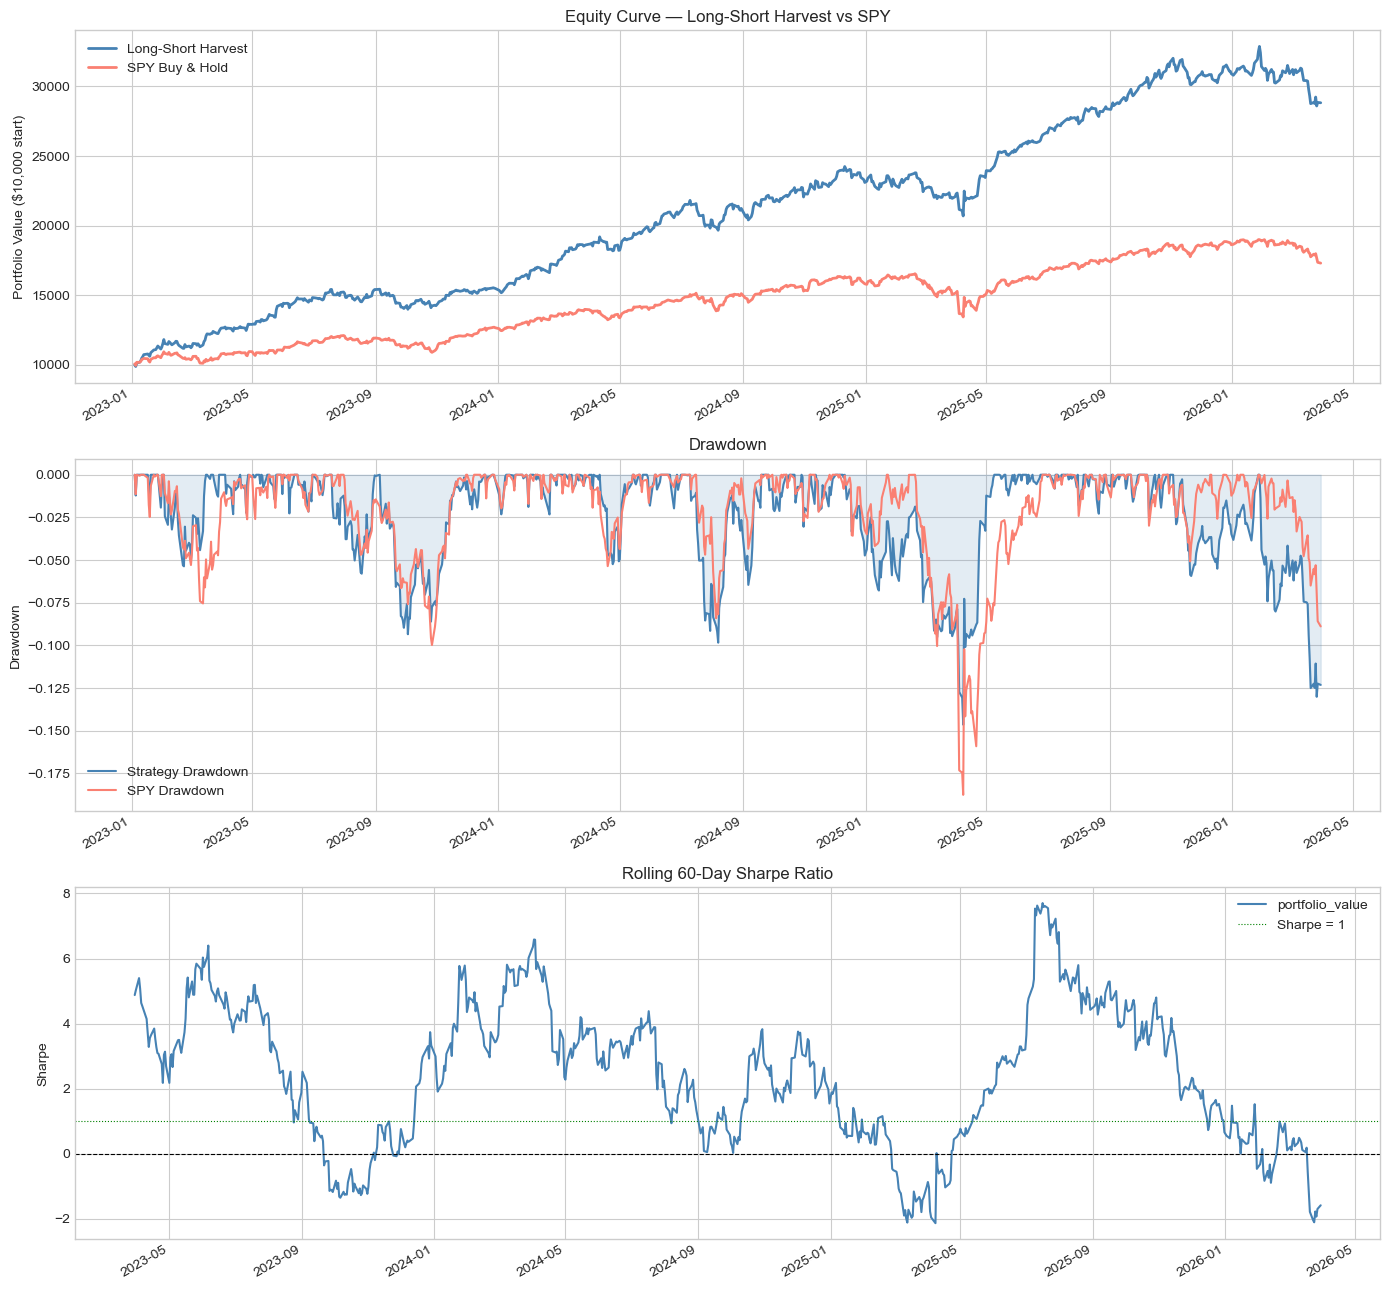

In [10]:
# ── Build return series ───────────────────────────────────────────────────────
port_returns = pv_df['portfolio_value'].pct_change().dropna()
port_returns = port_returns[~port_returns.index.duplicated(keep='last')]

spy_ret = spy_close.pct_change().dropna()
spy_ret.index = pd.to_datetime(spy_ret.index).tz_localize(None)
spy_ret = spy_ret[spy_ret.index >= TEST_START]
spy_ret = spy_ret[~spy_ret.index.duplicated(keep='last')]

common = port_returns.index.intersection(spy_ret.index)
port_r = port_returns.loc[common]
spy_r  = spy_ret.loc[common]

port_equity = (1 + port_r).cumprod() * INITIAL_CASH
spy_equity  = (1 + spy_r).cumprod()  * INITIAL_CASH
port_dd = port_equity / port_equity.cummax() - 1
spy_dd  = spy_equity  / spy_equity.cummax()  - 1

# ── Plots ─────────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(3, 1, figsize=(14, 13))

ax = axes[0]
port_equity.plot(ax=ax, label='Long-Short Harvest', color='steelblue', lw=2)
spy_equity.plot(ax=ax,  label='SPY Buy & Hold',     color='salmon',    lw=2)
ax.set_title('Equity Curve — Long-Short Harvest vs SPY')
ax.set_ylabel(f'Portfolio Value (${INITIAL_CASH:,} start)')
ax.legend()

ax = axes[1]
port_dd.plot(ax=ax, label='Strategy Drawdown', color='steelblue', lw=1.5)
spy_dd.plot(ax=ax,  label='SPY Drawdown',      color='salmon',    lw=1.5)
ax.fill_between(port_dd.index, port_dd, 0, alpha=0.15, color='steelblue')
ax.set_title('Drawdown')
ax.set_ylabel('Drawdown')
ax.legend()

ax = axes[2]
roll_sharpe = (port_r.rolling(60).mean() / port_r.rolling(60).std() * np.sqrt(252))
roll_sharpe.plot(ax=ax, color='steelblue', lw=1.5)
ax.axhline(0, color='black', lw=0.8, linestyle='--')
ax.axhline(1, color='green', lw=0.8, linestyle=':', label='Sharpe = 1')
ax.set_title('Rolling 60-Day Sharpe Ratio')
ax.set_ylabel('Sharpe')
ax.legend()

plt.tight_layout()
plt.show()

> 💬 **What this does:** Three charts to evaluate the strategy:

**Top — Equity curve**: How much $10,000 grew to over the test period, compared to just buying and holding SPY. If the blue line is above the red, the strategy outperformed.

**Middle — Drawdown**: How far the portfolio fell from its previous peak at any point. A drawdown of -20% means the account was 20% below its all-time high at that moment. Shallower drawdowns = smoother ride. This is often more important than raw returns for real trading.

**Bottom — Rolling Sharpe Ratio**: A 60-day rolling measure of return-per-unit-of-risk. Above 1 is good, above 2 is excellent, below 0 means the strategy was losing money in that period. This shows you *when* the strategy was working well vs struggling.


In [11]:
# ── Performance metrics ───────────────────────────────────────────────────────
def performance_metrics(returns: pd.Series, label: str, rf: float = 0.05):
    returns = returns.squeeze().dropna()
    daily_rf   = rf / 252
    ann_return = float(returns.mean() * 252)
    ann_vol    = float(returns.std() * np.sqrt(252))
    sharpe     = float((returns.mean() - daily_rf) / returns.std() * np.sqrt(252))
    equity     = (1 + returns).cumprod()
    max_dd     = float((equity / equity.cummax() - 1).min())
    win_rate   = float((returns > 0).mean())
    calmar     = ann_return / abs(max_dd) if max_dd != 0 else np.nan
    total_ret  = float(equity.iloc[-1] - 1)
    print(f'── {label} ──')
    print(f'  Total Return      : {total_ret:+.2%}')
    print(f'  Annualised Return : {ann_return:+.2%}')
    print(f'  Annualised Vol    : {ann_vol:.2%}')
    print(f'  Sharpe Ratio      : {sharpe:.2f}')
    print(f'  Max Drawdown      : {max_dd:.2%}')
    print(f'  Calmar Ratio      : {calmar:.2f}')
    print(f'  Win Rate (daily)  : {win_rate:.2%}')
    print()

performance_metrics(port_r, 'Long-Short Harvest')
performance_metrics(spy_r,  'SPY Buy & Hold')

── Long-Short Harvest ──
  Total Return      : +188.26%
  Annualised Return : +34.27%
  Annualised Vol    : 16.48%
  Sharpe Ratio      : 1.78
  Max Drawdown      : -14.64%
  Calmar Ratio      : 2.34
  Win Rate (daily)  : 56.97%

── SPY Buy & Hold ──
  Total Return      : +73.11%
  Annualised Return : +18.21%
  Annualised Vol    : 15.21%
  Sharpe Ratio      : 0.87
  Max Drawdown      : -18.76%
  Calmar Ratio      : 0.97
  Win Rate (daily)  : 56.47%



> 💬 **What this does:** A scorecard of the strategy's performance:

- **Total Return**: How much you made overall as a percentage
- **Annualised Return**: The average yearly return — what it averages out to per year
- **Annualised Volatility**: How much the daily returns bounced around. Lower is smoother.
- **Sharpe Ratio**: Return divided by risk. Above 1 is good — it means you were rewarded for the risk you took. SPY typically runs around 0.5–0.8.
- **Max Drawdown**: The worst peak-to-trough loss at any point. This is the number that keeps you up at night.
- **Calmar Ratio**: Annualised return divided by max drawdown. A ratio of 1 means you earned as much per year as your worst-ever drawdown — higher is better.
- **Win Rate**: What percentage of individual days were profitable. Most strategies sit around 50–55% — you don't need to be right most of the time if your wins are bigger than your losses.


In [12]:
# ── Trade analysis ────────────────────────────────────────────────────────────
if not trades_df.empty:
    print('Trade breakdown by reason:')
    print(trades_df['reason'].value_counts().to_string())
    print(f'\nUnique tickers traded: {trades_df["ticker"].nunique()}')
    print('\nMost active tickers:')
    print(trades_df['ticker'].value_counts().head(10).to_string())

Trade breakdown by reason:
reason
long_regime          2925
gld_regime            790
regime_exit           108
trail_stage1           27
trail_stage2            9
trail_stop              5
short_entry             2
short_exit_rescan       2

Unique tickers traded: 7

Most active tickers:
ticker
NVDA    806
GLD     790
AMZN    783
AAPL    769
MSFT    716
DELL      2
AXON      2


> 💬 **What this does:** A breakdown of every trade the strategy made, grouped by why it happened. This is useful for understanding which parts of the strategy are most active. For example, if 'short_stop' appears very frequently, it means the short sleeve is getting stopped out a lot — a signal that the stop might be too tight or the short candidates are being selected in a market that isn't cooperating.


## 8. Regime Analysis

Visualise which regime the strategy spent the most time in.

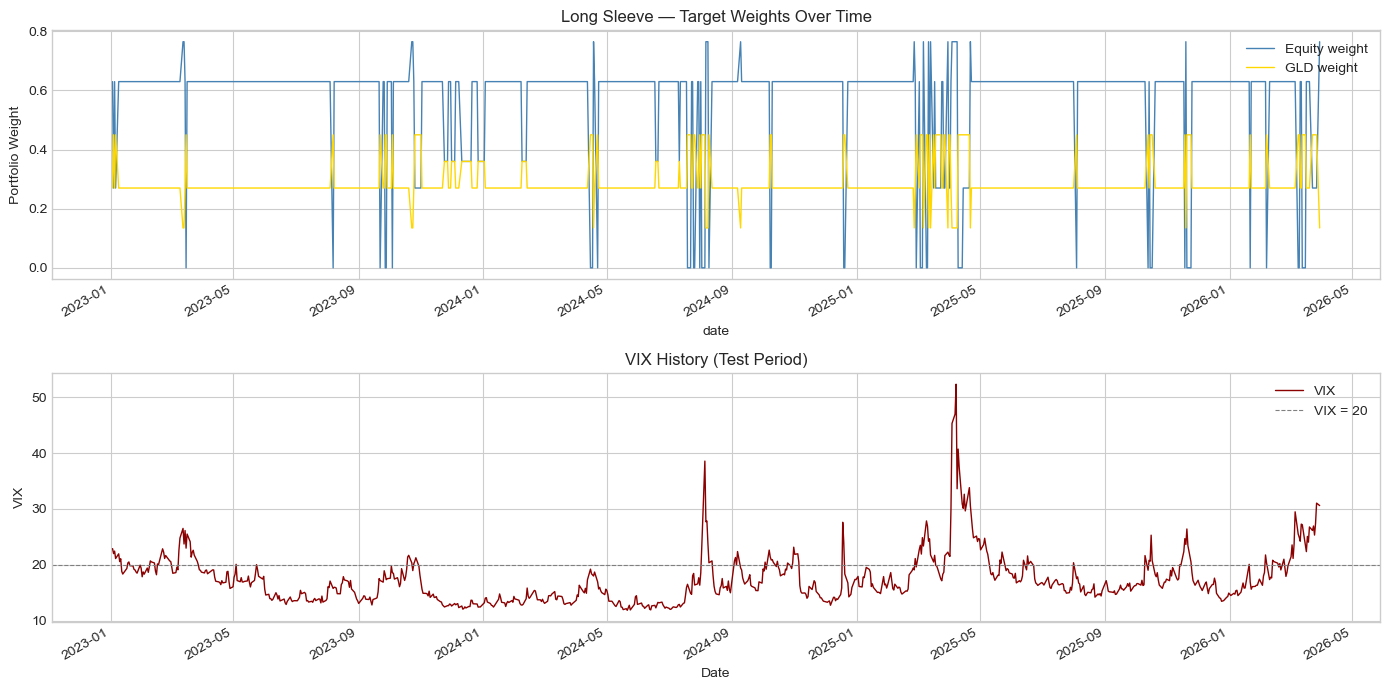

In [13]:
# Reconstruct regime history for analysis
regime_log = []
test_idx = spy_close.index[(spy_close.index >= TEST_START) & (spy_close.index <= TEST_END)]

for date in test_idx:
    full_loc = spy_close.index.get_loc(date)
    vix_arr  = vix_close.iloc[max(0, full_loc-100):full_loc].values
    spy_arr  = spy_close.iloc[max(0, full_loc-210):full_loc].values
    if len(vix_arr) < 50 or len(spy_arr) < 200:
        continue
    r = get_long_regime(vix_arr, spy_arr)
    regime_log.append({'date': date, 'equity_w': r['equity'], 'gld_w': r['gld']})

regime_df = pd.DataFrame(regime_log).set_index('date')

fig, axes = plt.subplots(2, 1, figsize=(14, 7))

ax = axes[0]
regime_df['equity_w'].plot(ax=ax, color='steelblue', lw=1, label='Equity weight')
regime_df['gld_w'].plot(ax=ax,    color='gold',      lw=1, label='GLD weight')
ax.set_title('Long Sleeve — Target Weights Over Time')
ax.set_ylabel('Portfolio Weight')
ax.legend()

ax = axes[1]
vix_plot = vix_close.loc[TEST_START:TEST_END]
vix_plot.plot(ax=ax, color='darkred', lw=1, label='VIX')
ax.axhline(20, color='grey', lw=0.8, linestyle='--', label='VIX = 20')
ax.set_title('VIX History (Test Period)')
ax.set_ylabel('VIX')
ax.legend()

plt.tight_layout()
plt.show()

> 💬 **What this does:** Two charts to understand the long sleeve's behaviour over time:

**Top**: The target equity weight (blue) and GLD weight (gold) through the test period. You can see the strategy pulling back from equities and rotating into gold during turbulent periods. Wide swings indicate frequent regime changes.

**Bottom**: The VIX itself. You can cross-reference spikes in VIX (fear) with the top chart to see how the regime engine responded — e.g. a VIX spike above 30 should correspond to a sharp drop in equity weight.


## 9. Parameter Reference

All tunable parameters are defined in **Cell 1** at the top. Key ones to experiment with:

| Parameter | Default | Effect |
|---|---|---|
| `LONG_GROSS` | 0.90 | Total gross long exposure cap |
| `SHORT_GROSS` | 0.60 | Total gross short exposure cap |
| `TOP_LONG_TICKERS` | AAPL/MSFT/NVDA/AMZN | Swap to whichever mega-caps you prefer |
| `ML_TILT` | 0.25 | How much extra weight the ML signal adds to the top stock |
| `SCORE_THRESHOLD` | 0.85 | Minimum Hurst score to short — lower = more shorts |
| `EXT_K` | 2.0 | Extension filter strictness — higher = only extreme extension |
| `MOM_K` | 1.75 | Momentum filter strictness |
| `STOP_ATR` | 2.0 | Short stop width in ATR multiples |
| `LONG_TRAIL_1/2/3` | 9.5% / 7% / 4.85% | Trailing stop stages for long sleeve |
| `TOP_N_SHORT` | 1 | Number of simultaneous shorts (increase to diversify) |
| `ML_RETRAIN_FREQ` | 21 | Days between ML retrains (~monthly) |

### Notes on the test period
This was a particularly difficult environment for this type of strategy:
- 2022 saw the sharpest VIX regime transitions in years (rate shock)
- The short sleeve targets trend-exhaustion which was rare in 2023–2024's grinding bull market
- Consider testing with `TEST_START = '2015-01-01'` to see full-cycle performance